In [31]:
from dotenv import load_dotenv
import os


### Setup ###
# Load variables from .env file
load_dotenv()

# Base Path for image folder
numpy_folder: str = os.getenv("NUMPY_FOLDER")

In [32]:
from core.validation import get_valid_image_number

# Define numpy file path
img_number: str = get_valid_image_number()
numpy_file_path: str = os.path.join(numpy_folder, f"{img_number}.npy")

print(numpy_file_path)

/home/renato/Pictures/PIBIC/NumpyFiles/000.npy


In [33]:
# https://numpy.org/doc/stable/reference/generated/numpy.load.html#numpy.load

import numpy as np
from numpy import ndarray

# Load numpy file
numpy_file = np.load(numpy_file_path)

# Create future validation errors for this step

In [34]:
# https://numpy.org/doc/stable/reference/generated/numpy.array_split.html#numpy.array_split

# Split numpy file in a list of masks
masks: list[ndarray] = np.split(ary=numpy_file, indices_or_sections=18, axis=2)
print(masks)
print(f"Masks length: {len(masks)}")

[array([[[0],
        [0],
        [0],
        ...,
        [0],
        [0],
        [0]],

       [[0],
        [0],
        [0],
        ...,
        [0],
        [0],
        [0]],

       [[0],
        [0],
        [0],
        ...,
        [0],
        [0],
        [0]],

       ...,

       [[0],
        [0],
        [0],
        ...,
        [0],
        [0],
        [0]],

       [[0],
        [0],
        [0],
        ...,
        [0],
        [0],
        [0]],

       [[0],
        [0],
        [0],
        ...,
        [0],
        [0],
        [0]]], dtype=uint8), array([[[0],
        [0],
        [0],
        ...,
        [0],
        [0],
        [0]],

       [[0],
        [0],
        [0],
        ...,
        [0],
        [0],
        [0]],

       [[0],
        [0],
        [0],
        ...,
        [0],
        [0],
        [0]],

       ...,

       [[0],
        [0],
        [0],
        ...,
        [0],
        [0],
        [0]],

       [[0],
        [0],
   

In [35]:
# Test: Accessing a mask
print(masks[0])


[[[0]
  [0]
  [0]
  ...
  [0]
  [0]
  [0]]

 [[0]
  [0]
  [0]
  ...
  [0]
  [0]
  [0]]

 [[0]
  [0]
  [0]
  ...
  [0]
  [0]
  [0]]

 ...

 [[0]
  [0]
  [0]
  ...
  [0]
  [0]
  [0]]

 [[0]
  [0]
  [0]
  ...
  [0]
  [0]
  [0]]

 [[0]
  [0]
  [0]
  ...
  [0]
  [0]
  [0]]]


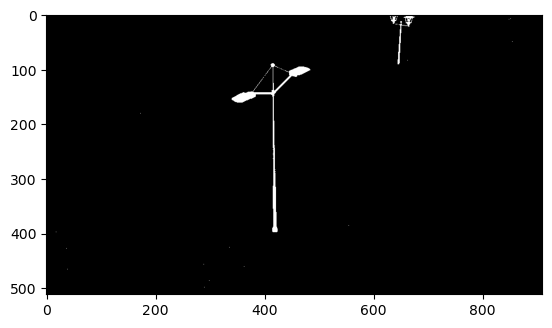

In [36]:
# 1st try: Matplotlib

# https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.imshow.html
# X= Array-like || Pillow Image
# cmap="gray" >>> binary mask
# interpolation="antialiased" >>> default

import matplotlib.pyplot as plt

plt.imshow(X=masks[0], cmap="gray", interpolation="antialiased")
plt.show()

# Ok, i can split and generate binary masks

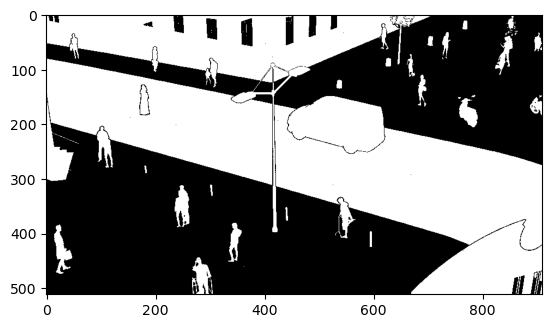

In [37]:
# https://numpy.org/doc/stable/reference/generated/numpy.sum.html
# https://numpy.org/doc/stable/reference/generated/numpy.clip.html
# https://numpy.org/doc/stable/reference/generated/numpy.ndarray.astype.html

# I need create a validation for layers format

# Adding layers
reconstructed_img = np.sum(masks, axis=0)

# Limiting values between 0 and 255 for the image
reconstructed_img = np.clip(reconstructed_img, 0, 255)

# Converting to uint8 type for saving as image
reconstructed_img = reconstructed_img.astype(np.uint8)

# Ploting the image
plt.imshow(reconstructed_img, cmap="gray", interpolation="antialiased")
plt.show()

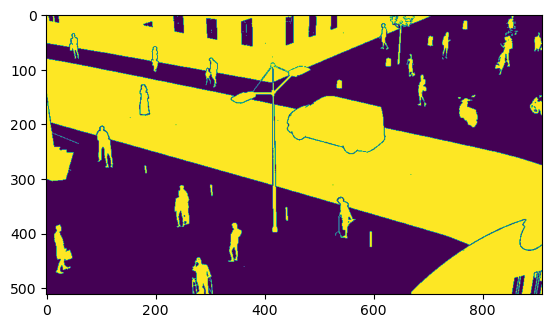

In [38]:
# Ploting the image
plt.imshow(reconstructed_img, cmap="viridis", interpolation="antialiased")
plt.show()